In [1]:
# --- Cell 1: imports + config ---
%load_ext autoreload
%autoreload 2
import sys, torch, numpy as np
sys.path.append('..')
sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from shared.pacs_protocol import build_loaders, next_source_batch
from task2.backbones.backbone import PACSModel, set_train_mode
from task2.training.train_loop import train_model
from task2.methods.dann import DANN, dann_alpha, grad_reverse

set_seed(6304)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CFG = dict(seed=6304, num_classes=7,
           batch_per_source=8, target_batch=24, eval_batch=64, num_workers=0,
           max_epochs=30, patience=5, lr=1e-4, weight_decay=1e-4,
           amp=False,
           disc_hidden=256, alpha_max=1.0, lambda_domain=1.0)
DATA_ROOT = '../../datasets/PACS'
print(CFG['amp'], CFG.get('grad_clip'), CFG['num_workers'])   # want False None 0

False None 0


In [2]:
# --- Cell 2: loaders ---
splits = load_results('../../shared/splits/pacs_sketch_seed6304.json')
loaders = build_loaders(DATA_ROOT, splits,
                        batch_per_source=CFG['batch_per_source'],
                        target_batch=CFG['target_batch'],
                        eval_batch=CFG['eval_batch'],
                        num_workers=CFG['num_workers'], seed=CFG['seed'])
print(f"steps/epoch={loaders['steps_per_epoch']}")

steps/epoch=203


In [3]:
# --- Cell 3: VERIFICATION ---
for p in [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]:
    print(f"p={p:.2f}  alpha={dann_alpha(p):.4f}")
# expect 0.0000, 0.4621, 0.8483, 0.9866, 0.9988, 0.9991

x = torch.ones(4, 512, requires_grad=True)
(x.sum()).backward(retain_graph=True)
plain = x.grad.clone(); x.grad = None

y = grad_reverse(x, 0.7)
(y.sum()).backward()
print(f"\nplain gradient   : {plain[0, 0].item():+.3f}")
print(f"reversed (a=0.7) : {x.grad[0, 0].item():+.3f}")   # must be -0.700
assert torch.allclose(x.grad, -0.7 * plain), "GRL is not reversing the gradient"
print("GRL reverses and scales correctly")

p=0.00  alpha=0.0000
p=0.10  alpha=0.4621
p=0.25  alpha=0.8483
p=0.50  alpha=0.9866
p=0.75  alpha=0.9989
p=1.00  alpha=0.9999

plain gradient   : +1.000
reversed (a=0.7) : -0.700
GRL reverses and scales correctly


In [4]:
# --- Cell 3b: DIAGNOSTIC — 400 steps with clipping, before committing to a full run ---
set_seed(6304)
probe = PACSModel(num_classes=7).to(device)
pm = DANN(CFG).to(device)
params = list(probe.parameters()) + list(pm.parameters())
opt = torch.optim.AdamW(params, lr=CFG['lr'], weight_decay=CFG['weight_decay'])
set_train_mode(probe); pm.disc.train()

total = loaders['steps_per_epoch'] * CFG['max_epochs']
for step in range(400):
    sx, sy = next_source_batch(loaders['source_train'], device)
    tx, _ = loaders['target_train'].next(); tx = tx.to(device)
    opt.zero_grad(set_to_none=True)
    loss, logs = pm.compute_loss(probe, sx, sy, tx, step / (total - 1))
    loss.backward()
    gn = torch.nn.utils.clip_grad_norm_(params, float('inf')).item()  # measure only, no clipping
    opt.step()
    if step % 25 == 0:
        with torch.no_grad():
            fnorm = probe(sx)[1].norm(dim=1).mean().item()
        print(f"step {step:3d}  cls={logs['loss_cls']:.3f}  dom={logs['loss_dom']:.3f}  "
              f"d_acc={logs['domain_acc']:.3f}  |f|={fnorm:6.1f}  gnorm={gn:8.1f}")

del probe, pm, opt; torch.cuda.empty_cache()

step   0  cls=2.379  dom=0.693  d_acc=0.500  |f|=  20.5  gnorm=    15.8
step  25  cls=0.934  dom=0.676  d_acc=0.771  |f|=  38.6  gnorm=    13.6
step  50  cls=0.478  dom=0.667  d_acc=0.708  |f|=  49.9  gnorm=    13.4
step  75  cls=0.283  dom=0.649  d_acc=0.896  |f|=  54.3  gnorm=     7.9
step 100  cls=0.302  dom=0.648  d_acc=0.875  |f|=  47.6  gnorm=    12.3
step 125  cls=0.124  dom=0.635  d_acc=0.792  |f|=  54.4  gnorm=     5.4
step 150  cls=0.535  dom=0.592  d_acc=0.875  |f|=  53.8  gnorm=    12.8
step 175  cls=0.621  dom=0.648  d_acc=0.667  |f|=  47.7  gnorm=    18.8
step 200  cls=0.126  dom=0.628  d_acc=0.688  |f|=  49.9  gnorm=     5.8
step 225  cls=0.259  dom=0.663  d_acc=0.562  |f|=  55.8  gnorm=    10.7
step 250  cls=0.059  dom=0.711  d_acc=0.396  |f|=  71.7  gnorm=     6.6
step 275  cls=0.069  dom=0.756  d_acc=0.333  |f|=  56.8  gnorm=     2.8
step 300  cls=0.230  dom=0.807  d_acc=0.062  |f|=  62.2  gnorm=    13.6
step 325  cls=0.215  dom=0.737  d_acc=0.125  |f|=  51.3  gnorm= 

In [5]:
# --- Cell 4: train DANN ---
set_seed(6304)                      # identical backbone init to the other methods
model = PACSModel(num_classes=CFG['num_classes']).to(device)
method = DANN(CFG).to(device)       # note the .to(device): the discriminator has weights

out = train_model(model, method, loaders, CFG, device,
                  ckpt_path='../../datasets/cache/task2_dann.pt')
print(out['best_epoch'], out['best_mean_macro_f1'], f"{out['minutes']:.1f} min")

ep01 loss_total=1.1374 loss_cls=0.5023 loss_dom=0.6351 domain_acc=0.8031 alpha=0.0826 train_acc=0.8192 | val photo=0.908 art_painting=0.853 cartoon=0.908 mean_f1=0.8895 | 50s
ep02 loss_total=0.9574 loss_cls=0.2413 loss_dom=0.7161 domain_acc=0.3722 alpha=0.2440 train_acc=0.9150 | val photo=0.941 art_painting=0.889 cartoon=0.916 mean_f1=0.9155 | 102s
ep03 loss_total=0.8691 loss_cls=0.1746 loss_dom=0.6945 domain_acc=0.4875 alpha=0.3931 train_acc=0.9423 | val photo=0.958 art_painting=0.861 cartoon=0.936 mean_f1=0.9182 | 154s
ep04 loss_total=0.8141 loss_cls=0.1235 loss_dom=0.6906 domain_acc=0.5282 alpha=0.5240 train_acc=0.9565 | val photo=0.947 art_painting=0.894 cartoon=0.934 mean_f1=0.9247 | 204s
ep05 loss_total=0.8024 loss_cls=0.1038 loss_dom=0.6986 domain_acc=0.4975 alpha=0.6341 train_acc=0.9645 | val photo=0.946 art_painting=0.883 cartoon=0.921 mean_f1=0.9168 | 256s
ep06 loss_total=0.7721 loss_cls=0.0799 loss_dom=0.6922 domain_acc=0.5268 alpha=0.7234 train_acc=0.9735 | val photo=0.943 

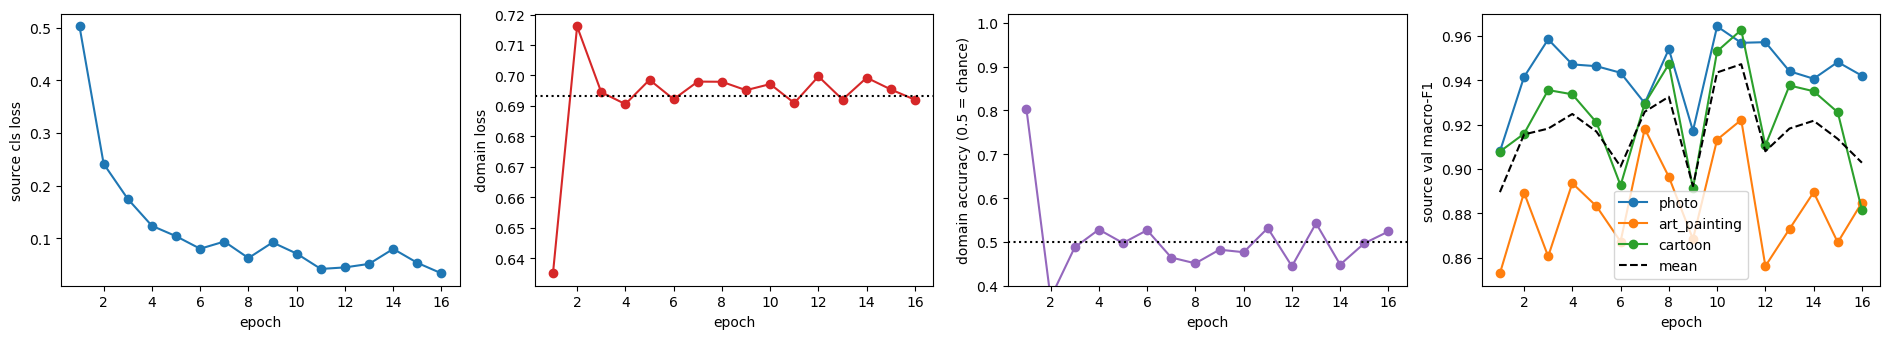

In [6]:
# --- Cell 5: save + curves ---
results = {'step': 'dann', 'seed': 6304, 'method': 'dann',
           'config': CFG, 'steps_per_epoch': loaders['steps_per_epoch'],
           'best_epoch': out['best_epoch'],
           'best_mean_macro_f1': out['best_mean_macro_f1'],
           'source_val_at_best': out['source_val_at_best'],
           'minutes': out['minutes'], 'history': out['history']}
save_results(results, '../results/dann.json')

import matplotlib.pyplot as plt
h = out['history']; ep = [r['epoch'] for r in h]
fig, ax = plt.subplots(1, 4, figsize=(19, 3.5))
ax[0].plot(ep, [r['loss_cls'] for r in h], marker='o'); ax[0].set_ylabel('source cls loss')
ax[1].plot(ep, [r['loss_dom'] for r in h], marker='o', color='tab:red')
ax[1].axhline(np.log(2), ls=':', c='k')          # ln 2 = 0.693: chance-level domain loss
ax[1].set_ylabel('domain loss')
ax[2].plot(ep, [r['domain_acc'] for r in h], marker='o', color='tab:purple')
ax[2].axhline(0.5, ls=':', c='k'); ax[2].set_ylim(0.4, 1.02)
ax[2].set_ylabel('domain accuracy (0.5 = chance)')
for d_ in splits['source_domains']:
    ax[3].plot(ep, [r['per_domain'][d_]['macro_f1'] for r in h], marker='o', label=d_)
ax[3].plot(ep, [r['mean_macro_f1'] for r in h], 'k--', label='mean')
ax[3].set_ylabel('source val macro-F1'); ax[3].legend()
for a_ in ax: a_.set_xlabel('epoch')
plt.tight_layout(); plt.savefig('../../report/figures/task2_dann_curves.png', dpi=200)
plt.show()